
# Phoneme Metrics — Robust Dashboard

This notebook computes and visualizes:
- **PER (Phoneme Error Rate)** per utterance and summary per model
- **Sectional PER by session**
- **Error rate by phoneme class** (vowels/stops/fricatives/...)

It uses a **regex-based parser** that handles list-like strings with odd quoting/brackets.

> **Edit the two paths below** if your CSVs are in a different location.


In [1]:
# --- Setup ---
import ast
import re
from typing import List, Tuple, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# For clean inline display
%matplotlib inline

# --- File paths (edit as needed) ---
GRU_PATH = "pred_results/phoneme_prediction_results.csv"
BILSTM_PATH = "pred_results/phoneme_prediction_results_lstm_bi.csv"
OUTPUT_DIR = "visualization"

print("GRU file:", GRU_PATH)
print("BiLSTM file:", BILSTM_PATH)
print("Outputs will be saved to:", OUTPUT_DIR)

GRU file: pred_results/phoneme_prediction_results.csv
BiLSTM file: pred_results/phoneme_prediction_results_lstm_bi.csv
Outputs will be saved to: visualization


In [2]:

# --- Imports & robust parsers ---
import re, ast, numpy as np, pandas as pd
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt

%matplotlib inline

PRED_COL = "pred_phonemes"
TRUE_COL = "true_phonemes"

def parse_phone_list_any(s: str) -> List[str]:
    """Extract ARPAbet-like phones regardless of CSV quoting/brackets."""
    if pd.isna(s):
        return []
    s = str(s)
    toks = re.findall(r"[A-Za-z]{1,3}[0-2]?", s)  # e.g., IY1, DH, Y
    toks = [re.sub(r"\d", "", t.upper()) for t in toks]  # IY1->IY
    return toks

def levenshtein(a: List[str], b: List[str]) -> int:
    n, m = len(a), len(b)
    if n == 0: return m
    if m == 0: return n
    dp = np.zeros((n+1, m+1), dtype=int)
    for i in range(n+1): dp[i,0] = i
    for j in range(m+1): dp[0,j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i,j] = min(dp[i-1,j]+1, dp[i,j-1]+1, dp[i-1,j-1]+cost)
    return int(dp[n,m])


In [6]:

# --- Load and compute PER ---
def compute_per_table(df: pd.DataFrame, model_name: str) -> Tuple[pd.DataFrame, float]:
    df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
    rows, empty_true = [], 0
    for idx, row in df.iterrows():
        pred = parse_phone_list_any(row[PRED_COL])
        true = parse_phone_list_any(row[TRUE_COL])
        if not true:
            empty_true += 1
            rows.append((idx, np.nan, 0, np.nan))
            continue
        dist = levenshtein(pred, true)
        rows.append((idx, dist, len(true), dist/len(true)))
    per_df = pd.DataFrame(rows, columns=["row_index","edit_distance","true_length","PER"])
    per_df["model"] = model_name
    print(f"[{model_name}] empty true rows: {empty_true}/{len(df)}")
    return per_df, float(np.nanmean(per_df["PER"]))

gru_df = pd.read_csv(GRU_PATH)
bilstm_df = pd.read_csv(BILSTM_PATH)

gru_per_df, gru_mean = compute_per_table(gru_df, "GRU (baseline)")
bi_per_df,  bi_mean  = compute_per_table(bilstm_df, "BiLSTM")

summary = pd.DataFrame({
    "Model": ["GRU (baseline)", "BiLSTM"],
    "Avg PER": [gru_mean, bi_mean],
    "Avg PER (%)": [gru_mean*100, bi_mean*100],
    "Num Utterances": [gru_per_df["PER"].notna().sum(), bi_per_df["PER"].notna().sum()]
}).sort_values("Avg PER")

summary


[GRU (baseline)] empty true rows: 0/41
[BiLSTM] empty true rows: 0/41


,Model,Avg PER,Avg PER (%),Num Utterances
1,BiLSTM,0.147317,14.731704,41
0,GRU (baseline),0.166965,16.696542,41


In [7]:

# --- Save CSVs ---
from pathlib import Path
OUTPUT_DIR = Path.cwd()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

(per_summary_path,
 per_utts_path) = (OUTPUT_DIR/"visualization/per_summary.csv", OUTPUT_DIR/"visualization/per_per_utterance.csv")

summary.to_csv(per_summary_path, index=False)
pd.concat([gru_per_df, bi_per_df], ignore_index=True).to_csv(per_utts_path, index=False)

str(per_summary_path), str(per_utts_path)


('c:\\Users\\miao\\VScodeProject\\2025brain-to-text\\metrics\\visualization\\per_summary.csv',
 'c:\\Users\\miao\\VScodeProject\\2025brain-to-text\\metrics\\visualization\\per_per_utterance.csv')

In [ ]:

# --- Sectional: PER by session ---
def per_by_session(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    sess_col = "session" if "session" in df.columns else None
    rows = []
    for _, row in df.iterrows():
        pred = parse_phone_list_any(row[PRED_COL])
        true = parse_phone_list_any(row[TRUE_COL])
        if not true: 
            continue
        dist = levenshtein(pred, true)
        per = dist/len(true)
        sess = row.get(sess_col, "unknown") if sess_col else "unknown"
        rows.append((sess, per))
    out = pd.DataFrame(rows, columns=["session","PER"]).groupby("session", as_index=False).agg(
        avg_PER=("PER","mean"), n=("PER","size"))
    out["model"] = model_name
    return out

by_sess_gru = per_by_session(gru_df, "GRU")
by_sess_bi  = per_by_session(bilstm_df, "BiLSTM")

by_session_all = pd.concat([by_sess_gru, by_sess_bi], ignore_index=True)
by_session_csv = OUTPUT_DIR/"visualization/sectional_by_session.csv"
by_session_all.to_csv(by_session_csv, index=False)
by_session_all


,session,avg_PER,n,model
0,"['t15.2023.08.13', 't15.2023.08.13', 't15.2023...",0.180328,1,GRU
1,"['t15.2023.08.18', 't15.2023.08.18', 't15.2023...",0.167031,1,GRU
2,"['t15.2023.08.20', 't15.2023.08.20', 't15.2023...",0.156153,1,GRU
3,"['t15.2023.08.25', 't15.2023.08.25', 't15.2023...",0.223762,1,GRU
4,"['t15.2023.08.27', 't15.2023.08.27', 't15.2023...",0.365702,1,GRU
...,...,...,...,...
77,"['t15.2025.01.12', 't15.2025.01.12', 't15.2025...",0.098901,1,BiLSTM
78,"['t15.2025.03.14', 't15.2025.03.14', 't15.2025...",0.391051,1,BiLSTM
79,"['t15.2025.03.16', 't15.2025.03.16', 't15.2025...",0.158784,1,BiLSTM
80,"['t15.2025.03.30', 't15.2025.03.30', 't15.2025...",0.325826,1,BiLSTM


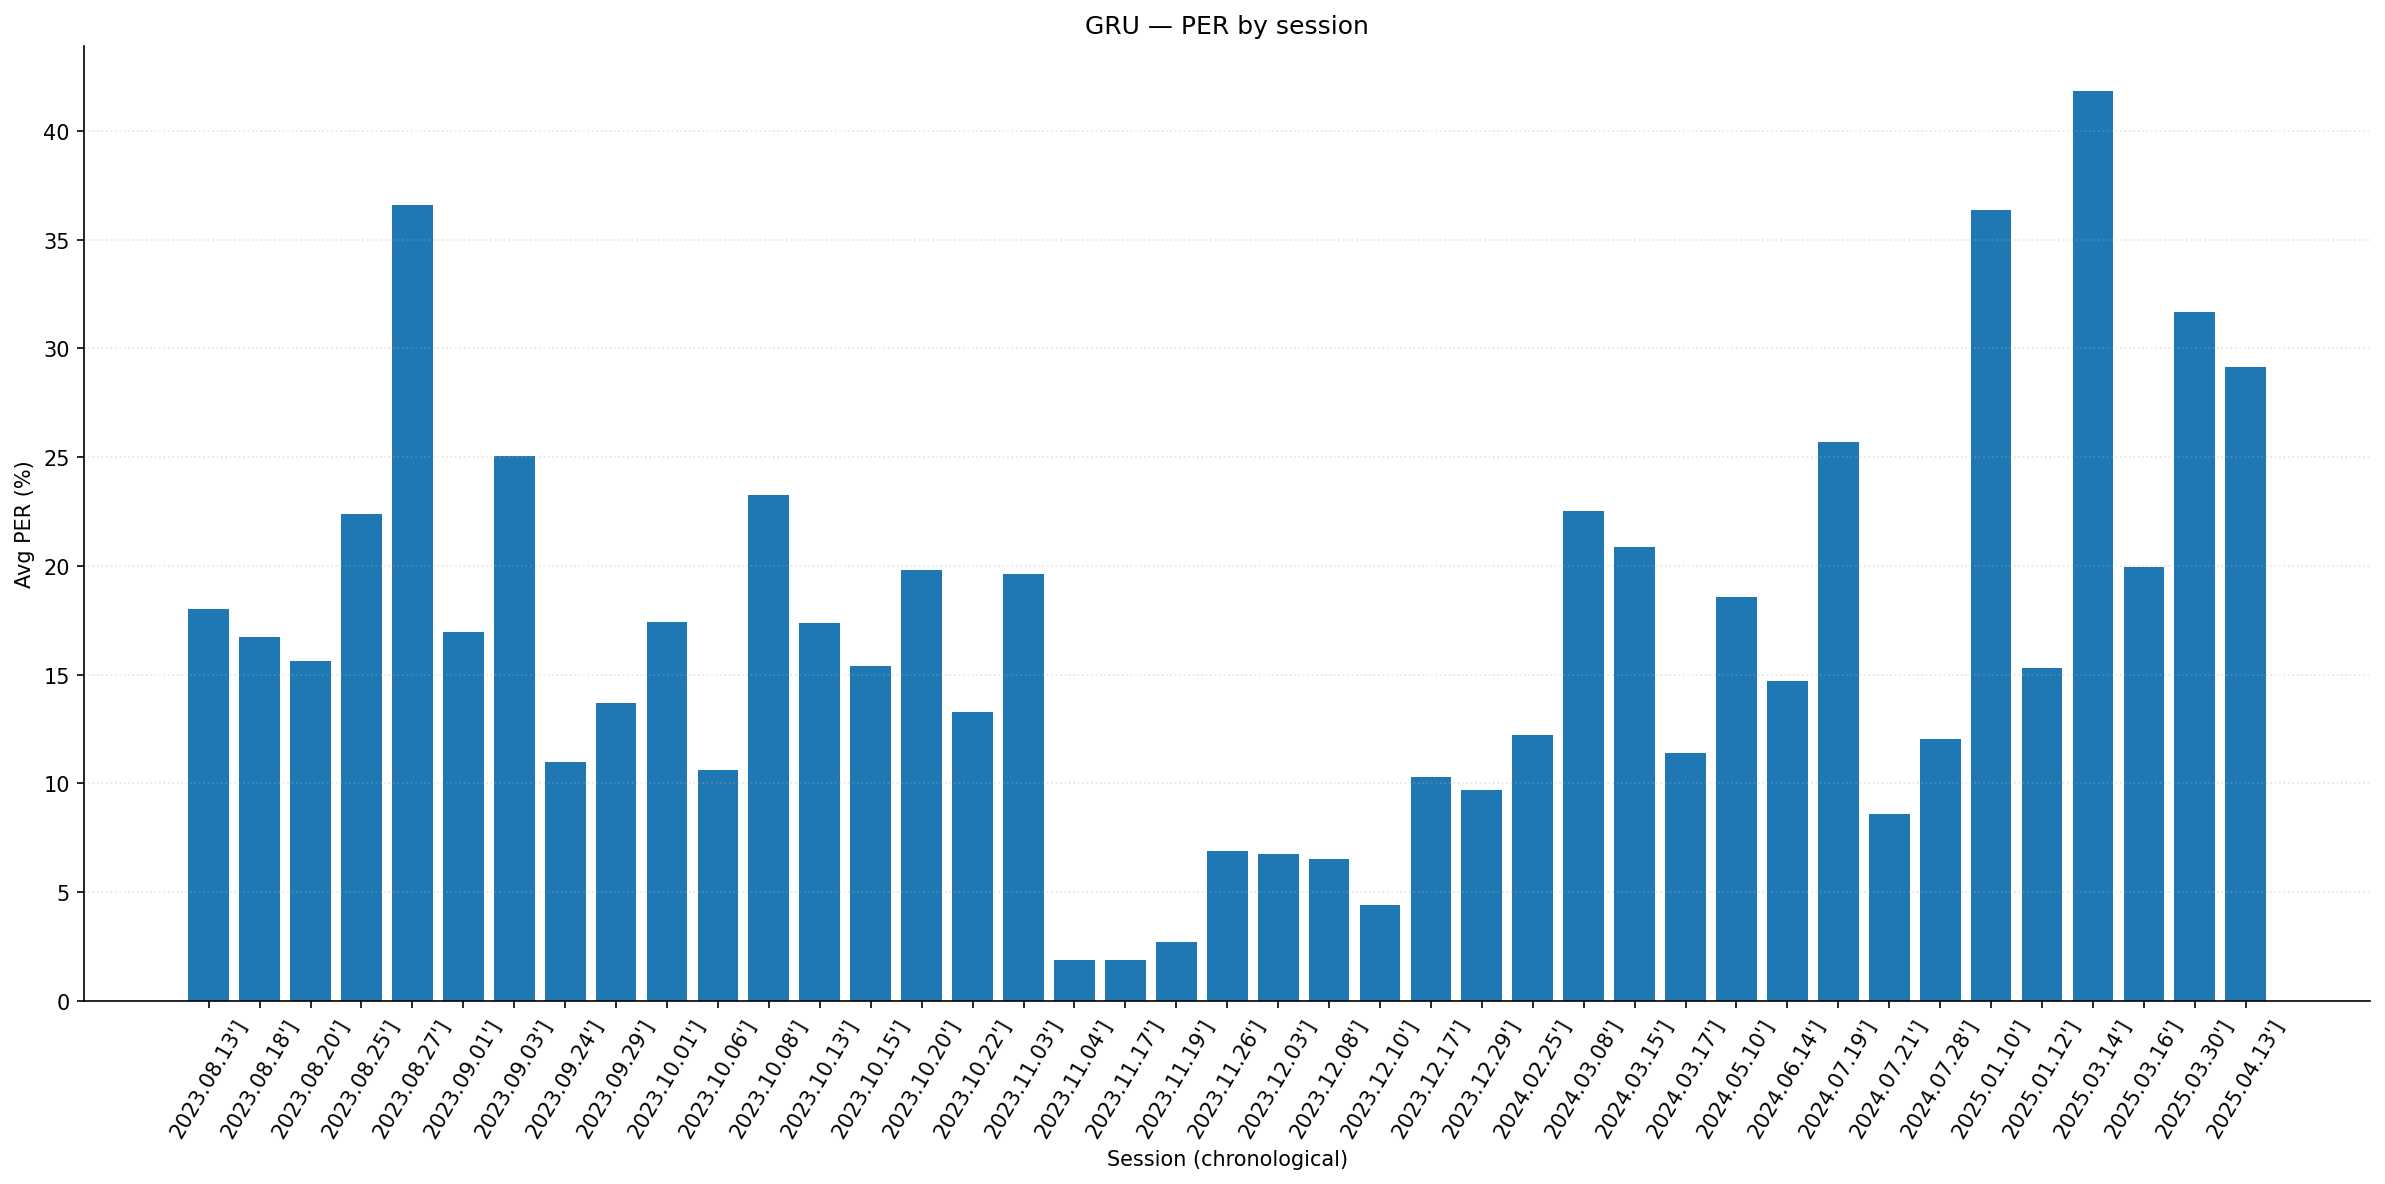

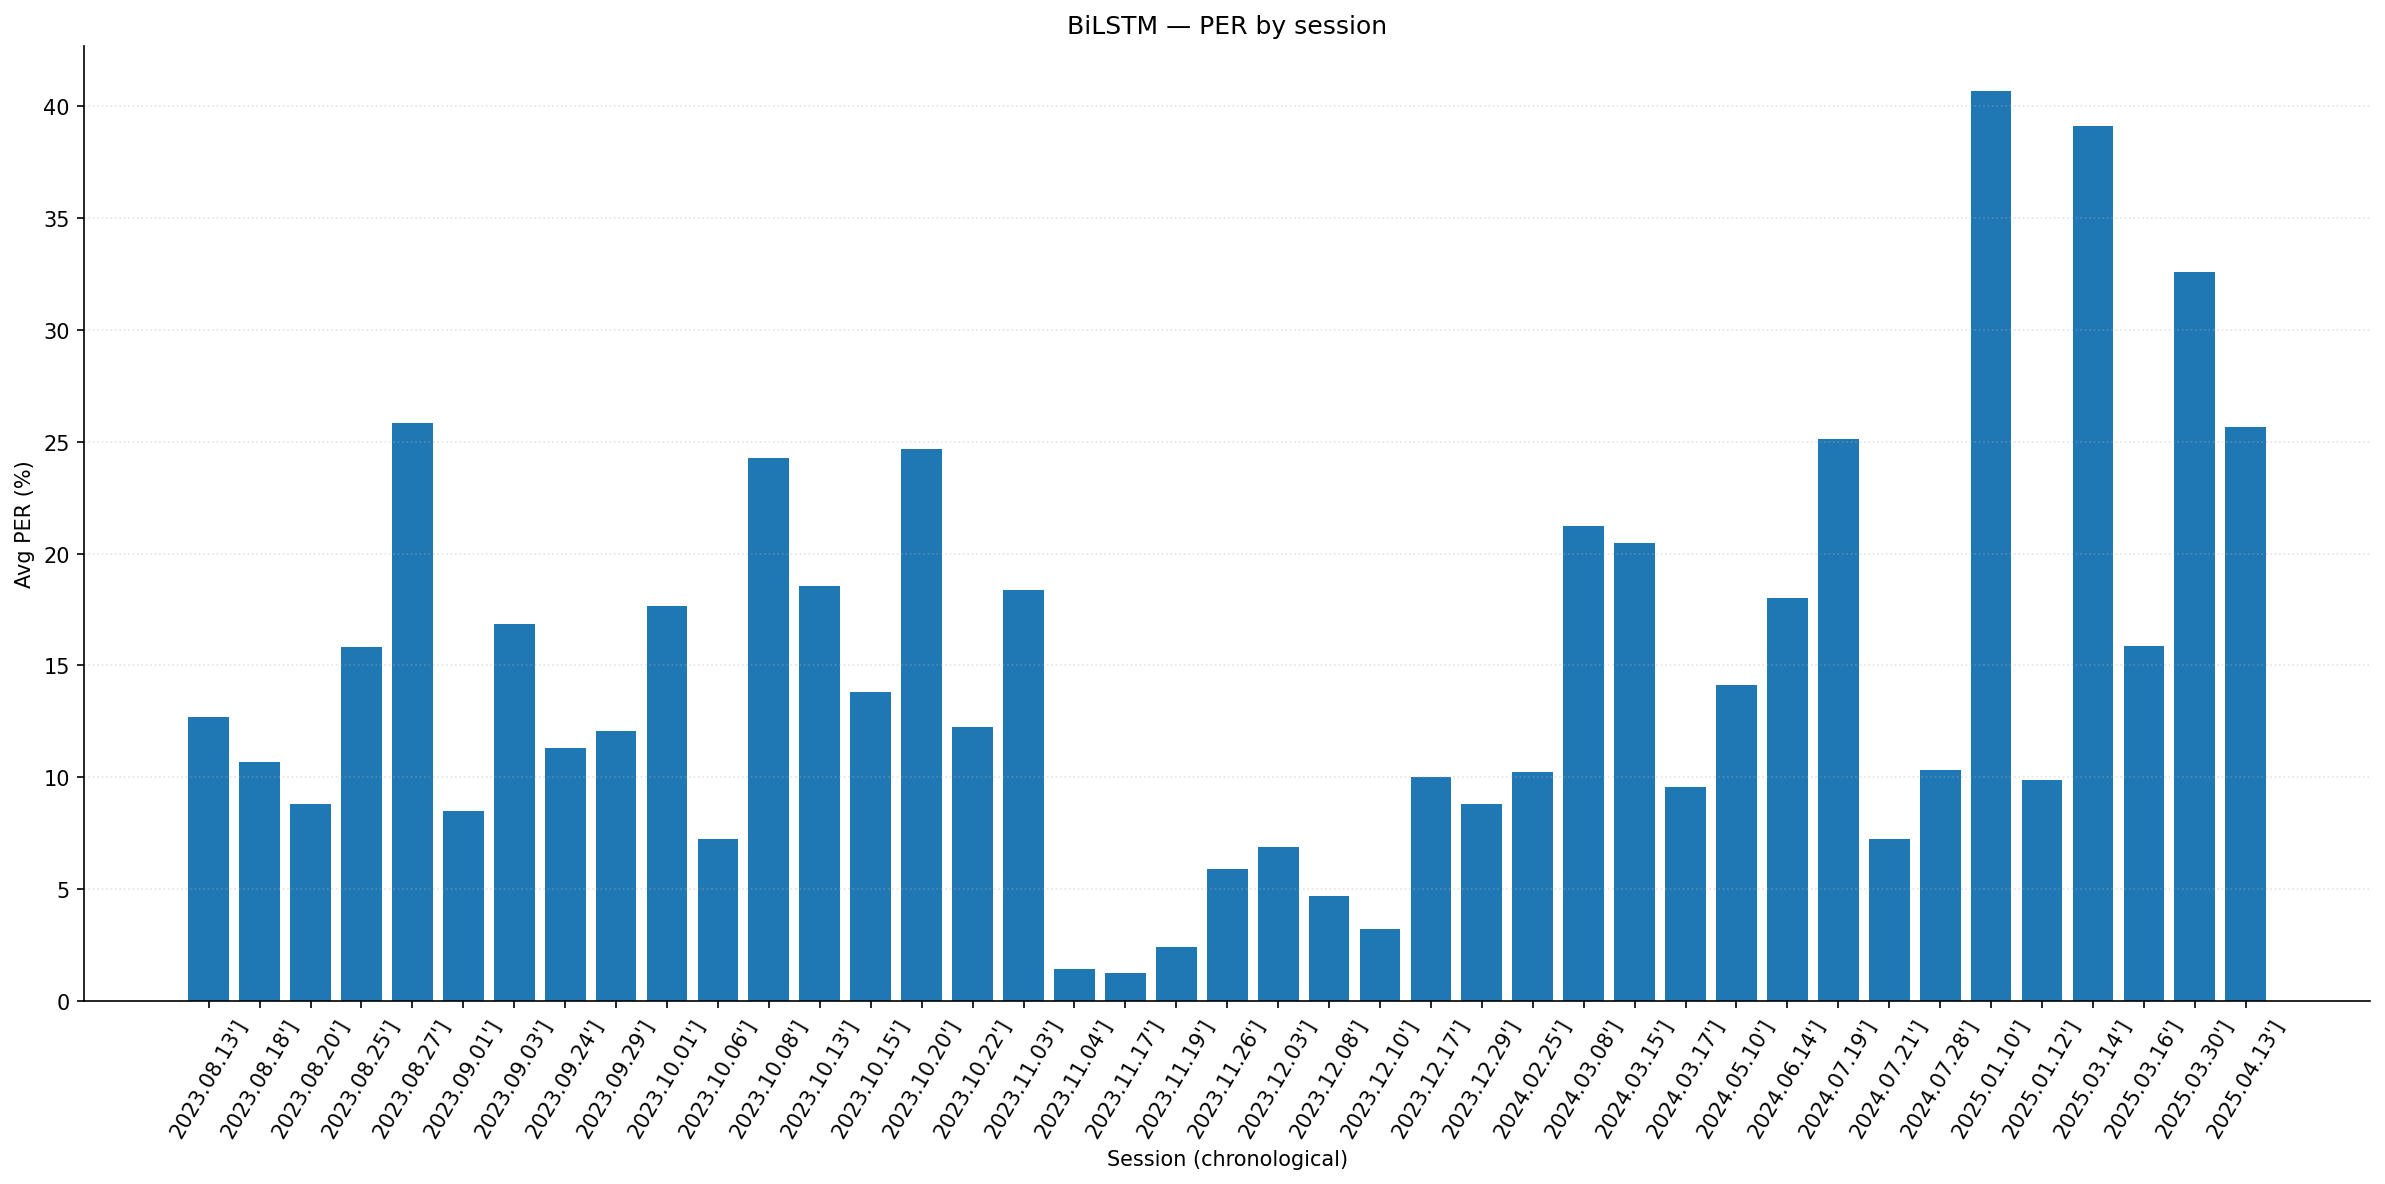

In [9]:
import re
import pandas as pd
import matplotlib.pyplot as plt

# Helper: try to extract a date from a session string like "t15.2023.08.11" or "2023-08-11"
_DATE_PATTERNS = [
    re.compile(r"(\d{4})[.\-_/](\d{2})[.\-_/](\d{2})"),  # YYYY.MM.DD or YYYY-MM-DD
    re.compile(r"(\d{8})"),                              # YYYYMMDD
]

def _parse_session_date(s: str):
    s = str(s)
    for pat in _DATE_PATTERNS:
        m = pat.search(s)
        if m:
            try:
                if len(m.groups()) == 3:
                    y, mo, d = m.groups()
                    return pd.Timestamp(int(y), int(mo), int(d))
                elif len(m.groups()) == 1 and len(m.group(1)) == 8:
                    y = int(m.group(1)[0:4]); mo = int(m.group(1)[4:6]); d = int(m.group(1)[6:8])
                    return pd.Timestamp(y, mo, d)
            except Exception:
                pass
    return pd.NaT

def _short_session_label(s):
    s = str(s)
    s = s.replace("t15.", "")           # adjust/remove stable prefix if you have one
    return s[-12:]                      # compact tail for display

def plot_per_by_session_time(df_sess: pd.DataFrame, title: str, figsize=(16, 8), dpi=150):
    # df_sess columns: ["session", "avg_PER", "n", "model"]
    d = df_sess.copy()

    # Try to get a chronological key from the session string
    d["session_dt"] = d["session"].astype(str).map(_parse_session_date)

    # Fallback order: first appearance in the original data if date missing
    # (ensures stable ordering instead of arbitrary sorting)
    if d["session_dt"].isna().all():
        d["first_idx"] = d["session"].astype(str).rank(method="dense")  # stable-ish fallback
        d = d.sort_values(["first_idx"]).drop(columns=["first_idx"])
    else:
        d = d.sort_values(["session_dt", "session"], ascending=[True, True])

    d["label"] = d["session"].astype(str).map(_short_session_label)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    ax.bar(d["label"], d["avg_PER"] * 100)
    ax.set_ylabel("Avg PER (%)")
    ax.set_xlabel("Session (chronological)")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=60)
    ax.grid(axis="y", linestyle=":", alpha=0.35)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    plt.show()
    
plot_per_by_session_time(by_sess_gru, "GRU — PER by session")
plot_per_by_session_time(by_sess_bi,  "BiLSTM — PER by session")

In [15]:

# --- Sectional: Error by phoneme class ---
# VOWELS = {"AA","AE","AH","AO","AW","AY","EH","ER","EY","IH","IY","OW","OY","UH","UW","AX","IX","UX","AXR"}
# STOPS = {"P","B","T","D","K","G"}
# AFFRICATES = {"CH","JH"}
# FRICATIVES = {"F","V","TH","DH","S","Z","SH","ZH","HH"}
# NASALS = {"M","N","NG"}
# LIQUIDS = {"L","R"}
# GLIDES = {"W","Y"}
# SILENCE = {"SIL","SP","SPN","NSN"}

# def phone_class(p: str) -> str:
#     if p in VOWELS: return "vowel"
#     if p in STOPS: return "stop"
#     if p in AFFRICATES: return "affricate"
#     if p in FRICATIVES: return "fricative"
#     if p in NASALS: return "nasal"
#     if p in LIQUIDS: return "liquid"
#     if p in GLIDES: return "glide"
#     if p in SILENCE: return "silence"
#     return "other"

VOWELS     = {"AA","AE","AH","AO","AW","AY","EH","ER","EY","IH","IY","OW","OY","UH","UW"}
STOPS      = {"P","B","T","D","K","G"}
AFFRICATES = {"CH","JH"}
FRICATIVES = {"F","V","TH","DH","S","Z","SH","ZH"}
ASPIRATE   = {"HH"}
NASALS     = {"M","N","NG"}
LIQUIDS    = {"L","R"}
SEMIVOWELS = {"W","Y"}
SILENCE    = {"|"}

def phone_class(p: str) -> str:
    if p in VOWELS: return "vowel"
    if p in STOPS: return "stop"
    if p in AFFRICATES: return "affricate"
    if p in FRICATIVES: return "fricative"
    if p in ASPIRATE: return "aspirate"
    if p in NASALS: return "nasal"
    if p in LIQUIDS: return "liquid"
    if p in SEMIVOWELS: return "semivowel"
    if p in SILENCE: return "silence"
    return "other"

def align_ops(a: list, b: list):
    n, m = len(a), len(b)
    dp = np.zeros((n+1, m+1), dtype=int)
    back = [[None]*(m+1) for _ in range(n+1)]
    for i in range(n+1):
        dp[i,0] = i
        if i>0: back[i][0] = ('del', a[i-1], '')
    for j in range(m+1):
        dp[0,j] = j
        if j>0: back[0][j] = ('ins', '', b[j-1])
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = 0 if a[i-1]==b[j-1] else 1
            choices = [
                (dp[i-1,j]+1, ('del', a[i-1], '')),
                (dp[i,j-1]+1, ('ins', '', b[j-1])),
                (dp[i-1,j-1]+cost, ('eq' if cost==0 else 'sub', a[i-1], b[j-1]))
            ]
            dp[i,j], back[i][j] = min(choices, key=lambda x:x[0])
    i, j = n, m
    ops = []
    while i>0 or j>0:
        op = back[i][j]
        ops.append(op)
        if op[0]=='del': i -= 1
        elif op[0]=='ins': j -= 1
        else: i -= 1; j -= 1
    ops.reverse()
    return ops

def class_error_table(df: pd.DataFrame, model_name: str) -> pd.DataFrame:
    df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")
    totals, errors = {}, {}
    for _, row in df.iterrows():
        pred = parse_phone_list_any(row[PRED_COL])
        true = parse_phone_list_any(row[TRUE_COL])
        if not true: 
            continue
        # for op, p_pred, p_true in align_ops(pred, true):
        #     if op == "ins":
        #         continue

        for op, p_pred, p_true in align_ops(pred, true):
            if not p_true:   # only skip steps with no true phone (i.e., deletions from true's side)
                continue
            cls = phone_class(p_true)
            totals[cls] = totals.get(cls, 0) + 1
            if op != "eq":
                errors[cls] = errors.get(cls, 0) + 1

    classes = sorted(set(totals) | set(errors))
    rows = []
    for cls in classes:
        tot = totals.get(cls, 0)
        err = errors.get(cls, 0)
        rate = (err/tot) if tot>0 else np.nan
        rows.append((cls, tot, err, rate))
    out = pd.DataFrame(rows, columns=["phoneme_class","true_tokens","errors_on_true","class_error_rate"])
    out["model"] = model_name
    return out.sort_values("class_error_rate", ascending=False)

class_gru = class_error_table(gru_df, "GRU")
class_bi  = class_error_table(bilstm_df, "BiLSTM")

class_all = pd.concat([class_gru, class_bi], ignore_index=True)
class_csv = OUTPUT_DIR/"visualization/sectional_by_phoneme_class.csv"
class_all.to_csv(class_csv, index=False)
class_all


,phoneme_class,true_tokens,errors_on_true,class_error_rate,model
0,aspirate,454,95,0.209251,GRU
1,affricate,354,68,0.192090,GRU
2,stop,6270,998,0.159171,GRU
3,vowel,12562,1963,0.156265,GRU
4,nasal,3277,435,0.132743,GRU
5,fricative,5102,554,0.108585,GRU
6,liquid,2732,288,0.105417,GRU
7,semivowel,1196,99,0.082776,GRU
8,affricate,354,71,0.200565,BiLSTM
9,aspirate,454,90,0.198238,BiLSTM


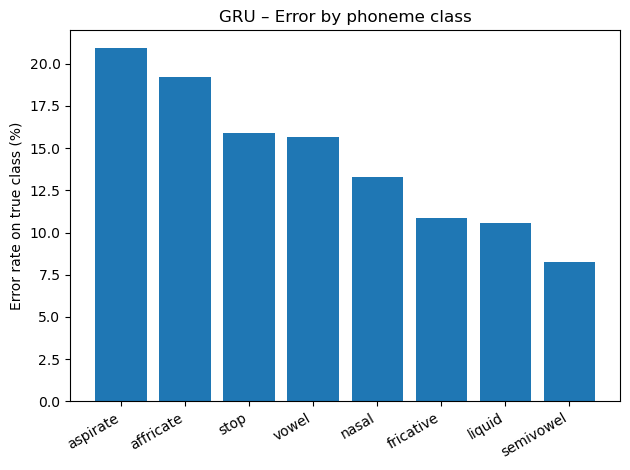

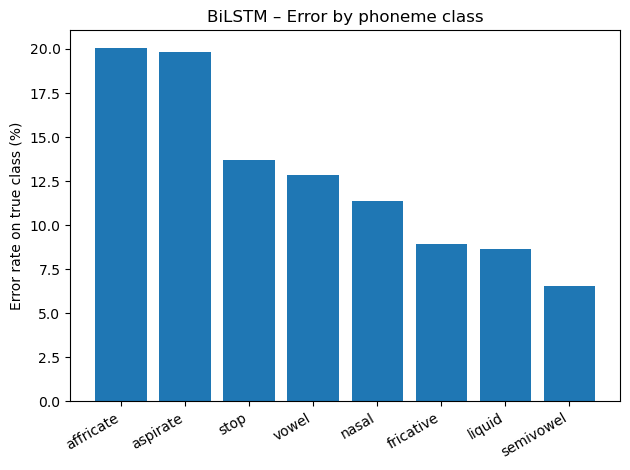

In [16]:

# --- Plot: error by phoneme class ---
plt.figure()
plt.bar(class_gru["phoneme_class"], class_gru["class_error_rate"]*100)
plt.ylabel("Error rate on true class (%)")
plt.title("GRU – Error by phoneme class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
plt.bar(class_bi["phoneme_class"], class_bi["class_error_rate"]*100)
plt.ylabel("Error rate on true class (%)")
plt.title("BiLSTM – Error by phoneme class")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()
